# Configuration

In [1]:
import os 

if True ^ os.getcwd().endswith('hte-and-targeting'):
    os.chdir('..')

In [2]:
import random
import pandas as pd 
import numpy as np

from tqdm import tqdm

In [3]:
from scipy.integrate import quad 

In [4]:
# visualization
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
from core.variables import *

# Smooth v.s. Nonsmooth Estimators

In [13]:
sample_size = 50
var_list = [
    UnivariateGaussian(mean=0, std=1), UnivariateGaussian(mean=1, std=0.5),
    UnivariateExponential(rate=1), UnivariateExponential(rate=0.5),
]
data_arr = np.array([var.sample(sample_size) for var in var_list]).T

def exp_of_max(var_list):
    """ 
    Given a list of CONTINUOUS random variables, calculate the expectation of the max of the random variables numerically. 
    """
    def pdf(x):
        result_arr = np.zeros(shape=(len(var_list),))

        for idx in range(len(var_list)):
            result_arr[idx] = var_list[idx].pdf(x) * np.prod([var.cdf(x) for j, var in enumerate(var_list) if j != idx])

        return np.sum(result_arr)
    return quad(lambda x: x * pdf(x), -500, 500)[0]

def exp_of_sum(var_list):
    """ 
    Given a list of CONTINUOUS random variables, calculate the expectation of the sum of the random variables numerically. 
    """
    return np.sum([var.mean for var in var_list])

In [14]:
def nonparam_bootstrap_exp_of_max(data: np.ndarray, n_bootstraps: int = 100) -> float:
    """
    Given a list of random variables, calculate the expectation of the max of the random variables using nonparametric bootstrap. 
    """
    boot_sample = np.zeros(shape=(n_bootstraps, data.shape[1]))
    for d in range(data.shape[1]):
        boot_sample[:, d] = np.random.choice(data[:, d], size=n_bootstraps, replace=True)

    return np.mean(np.max(boot_sample, axis=1))

def nonparam_bootstrap_exp_of_sum(data: np.ndarray, n_bootstraps: int = 100) -> float:
    """
    Given a list of random variables, calculate the expectation of the sum of the random variables using nonparametric bootstrap. 
    """
    boot_sample = np.zeros(shape=(n_bootstraps, data.shape[1]))
    for d in range(data.shape[1]):
        boot_sample[:, d] = np.random.choice(data[:, d], size=n_bootstraps, replace=True)

    return np.mean(np.sum(boot_sample, axis=1))

def replicate(var_list, n_repeats: int, sample_size: int, est_func: callable, est_params: dict) -> np.ndarray:
        return np.array([
            est_func(
                data=np.array([var.sample(sample_size) for var in var_list]).T, 
                **est_params
            ) for _ in range(n_repeats)
        ])
    
nonparam_boot_max_est_arr = replicate(
    var_list=var_list, 
    n_repeats=1000, 
    sample_size=100, 
    est_func=nonparam_bootstrap_exp_of_max, 
    est_params={'n_bootstraps': 100}
)
nonparam_boot_sum_est_arr = replicate(
    var_list=var_list, 
    n_repeats=1000, 
    sample_size=100, 
    est_func=nonparam_bootstrap_exp_of_sum, 
    est_params={'n_bootstraps': 100}
)

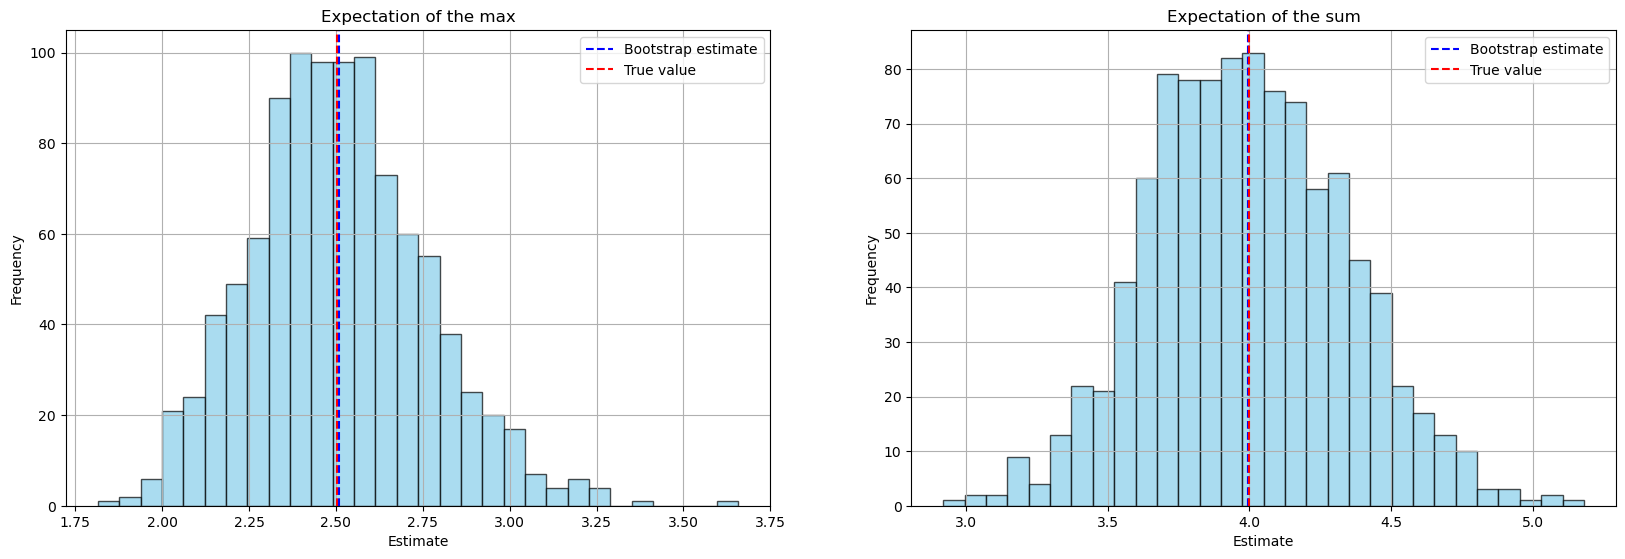

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(20, 6.18))

# 1. Expectation of the max
axes[0].hist(nonparam_boot_max_est_arr, bins=30, color='skyblue', edgecolor='black', alpha=0.7)
axes[0].axvline(np.mean(nonparam_boot_max_est_arr), color='blue', linestyle='--', label='Bootstrap estimate')
axes[0].axvline(exp_of_max(var_list), color='red', linestyle='--', label='True value')
axes[0].set_title('Expectation of the max')

# 2. Expectation of the sum
axes[1].hist(nonparam_boot_sum_est_arr, bins=30, color='skyblue', edgecolor='black', alpha=0.7)
axes[1].axvline(np.mean(nonparam_boot_sum_est_arr), color='blue', linestyle='--', label='Bootstrap estimate')
axes[1].axvline(exp_of_sum(var_list), color='red', linestyle='--', label='True value')
axes[1].set_title('Expectation of the sum')

for ax in axes:
    ax.legend()
    ax.grid()
    ax.set_xlabel('Estimate')
    ax.set_ylabel('Frequency')

plt.show()